# ***DATASET CURADO***

---



#**1-1 Contexto: Limpieza y preparación de datos sobre accidentes de tránsito para entrenamiento**
En el cuaderno se documenta el proceso de limpieza y preparación de datos sobre accidentes viales para utilizar los mismos en la etapa de modelado y entrenamiento en machine learning.

# **GRUPO 7**
# **Proyecto: Sistema predictivo de accidentes en rutas**
**Problema:** Se identifica una relación constante entre diferentes variables y la ocurrencia de accidentes en rutas nacionales.

**Datos disponibles:** Se dispone de una base de datos sintética, la cual se usará para entrenamiento.

**Objetivos:**
*   Identificar y conservar los datos necesarios para la etapa de modelado.
*   Eliminar filas duplicadas y filas sin datos.
*   Corregir valores atípicos (outliers).
*   Establecer validar y evidenciar relaciones lógicas entre variables.
*   Acotar el dataset a aquellos datos que signifiquen situaciones predecibles en condiciones normales de uso de las vías.


###**Acciones principales a realizar:**


*   Referenciar la fuente de la base de datos sintética a utilizar para entrenamiento.
*   Cargar el dataset usando pandas.read_csv()
*   Explorar la estructura inicial (filas, columnas, tipos de datos, etc)
*   Detectar valores faltantes y evaluar el impacto.
*   Eliminar filas con demasiados faltantes.
*   Identificar y eliminar filas duplicadas si las hubiera.
*   Corregir tipos de datos (variables numéricas, categoricas).
*   Detectar valores atipicos en variables relevantes, consentrándonos en los casos habituales (no solo los posibles).
*   Imputar valores faltantes usando la mediana o moda.
*   Realizar validaciones logicas (relaciones entre variables).
*   Generar graficos desde Pandas para exponer las validaciones.
*   Generar y guardar el dataset limpio  para etapas posteriores.



In [ ]:
# Se importa la libreria Pandas con el alias "pd".
import pandas as pd

# **1-2- Dataset**
**Tipo de data set:** Sintético.

**Justificación del tipo de dataset:**

Se decide trabajar con datos sintéticos debido a que no se dispone en la actualidad de datos reales de acceso libre para la zona en la que sería aprovechado el modelo predictivo, no obstante se considera óptimo para el entrenamiento del modelo manejar grandes volúmenes de datos. El resultado a su vez se considera escalable al problema original en la provincia de Córdoba, si se contara con los datos reales en un futuro o a cualquier otra locación condiderando características culturales y de contexto similares.

**Justificación de la creación del dataset:**

De común acuerdo entre las partes del equipo se decide **crear un dataset** (tarea a cargo del equipo de desarrolladores) con el **objetivo de generar grandes volumenes de datos que presenten la menor cantidad de inconsistencias posibles**.

De esta forma se definirá en un futuro en la medida que sea necesario aumentar la cantidad de filas generadas, corregir atributos o lo que sea necesario para que los resultados sean representativos.

**Las reglas sobre las cuales se crearon los datos fueron validadas por el equipo experto.**

**Formato:** csv

**Aclaraciones:** Se carga el CSV en un Dataframe de Pandas. Se trabajará sobre dicho dataframe que se llamará "df", siendo el mismo la tabla principal de trabajo.

El archivo se encuentra ubicado en: [link de archivo en carpeta drive](https://drive.google.com/file/d/1UNrxTGo5UgrlNPlMIwMngHPFNxz7M9W5/view?usp=drive_link)


In [ ]:
# Se importa la función de "drive" de google.colab para acceder al dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/IA- Sistema predictivo de accidentes en rutas/00- Datasets/dataset_entrenamiento.csv")

# **2-1- Exploracion inicial del dataset, conclusiones y acciones a efectuar**
*   Se identifican la cantidad de filas y columnas del dataset y el tipo de datos que compone cada columna.
*   Se realizan las primeras observaciones sobre los datos.
*   Se realiza un resumen estadistico de las variables.

**Objetivo:** Sacar conclusiones respecto del estado del dataset original.


In [ ]:
# Se definen las dimensiones del dataset. Identifica la cantidad de filas y columnas. Se cuenta con 840 registros generados de manera sintética.
print("Dimensiones (filas, columnas):", df.shape)

# Se muestran las primeras filas del df para reconocer el tipo de dato que contiene cada columna. Se identifican datos numéricos y categóricos.
display(df.head())

# Información general (tipos de datos y valores no nulos)
df.info()

# Estadísticas básicas para columnas numéricas
df.describe()

Dimensiones (filas, columnas): (2000, 14)


,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
0,Despejado,Camino Rural,Atardecer,0.0,70.0,3.0,0.0,NaN,Seco,Camion,49.0,23.0,NaN,0.0
1,Despejado,Camino Urbano,Tarde,2.0,30.0,2.0,1.0,Media,Seco,Auto,22.0,3.0,Luz Diurna,1.0
2,Despejado,Autopista,Atardecer,0.0,100.0,3.0,0.0,NaN,Seco,Moto,41.0,7.0,Luz Diurna,0.0
3,Lluvioso,Camino Urbano,Tarde,2.0,40.0,1.0,0.0,NaN,Mojado,Auto,80.0,24.0,Luz Diurna,0.0
4,Despejado,Autopista,Noche,1.0,110.0,2.0,0.0,NaN,Seco,Bus,32.0,6.0,Luz Artificial,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Clima                          2000 non-null   object 
 1   Tipo_de_Camino                 1892 non-null   object 
 2   Momento_del_Día                2000 non-null   object 
 3   Densidad_de_Tráfico            2000 non-null   float64
 4   Límite_de_Velocidad            2000 non-null   float64
 5   Número_de_Vehículos            2000 non-null   float64
 6   Alcohol_en_Conductor           2000 non-null   float64
 7   Severidad_del_Accidente        1141 non-null   object 
 8   Condición_del_Camino           1931 non-null   object 
 9   Tipo_de_Vehículo               2000 non-null   object 
 10  Edad_del_Conductor             2000 non-null   float64
 11  Experiencia_del_Conductor      2000 non-null   float64
 12  Condición_de_Iluminación_Vial  1963 non-null   o

,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Edad_del_Conductor,Experiencia_del_Conductor,Accidente
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.178500,66.125000,2.980500,0.066000,45.050000,13.713500,0.570500
std,0.790538,26.886722,1.581888,0.248344,14.251844,11.670884,0.495129
min,0.000000,30.000000,1.000000,0.000000,18.000000,0.000000,0.000000
25%,1.000000,40.000000,2.000000,0.000000,35.000000,4.000000,0.000000
50%,1.000000,60.000000,3.000000,0.000000,45.000000,11.000000,1.000000
75%,2.000000,90.000000,4.000000,0.000000,55.000000,21.000000,1.000000
max,2.000000,120.000000,10.000000,1.000000,80.000000,60.000000,1.000000


###**2-1-1 En base a los NaN, filas repetidas y el tipo de datos**

In [ ]:
# Identificar y separar las columnas con valores nulos
columnas_con_nulos = df.columns[df.isna().any()]

# Mostrar dichas columnas y la cantidad de valores nulos que contienen
df[columnas_con_nulos].isna().sum()

,0
Tipo_de_Camino,108
Severidad_del_Accidente,859
Condición_del_Camino,69
Condición_de_Iluminación_Vial,37


In [ ]:
# Identificar cantidad de NaN por cada fila
na_per_row = df.isna().sum(axis=1)
na_per_row

,0
0,2
1,0
2,1
3,1
4,1
...,...
1995,0
1996,0
1997,1
1998,1


In [ ]:
# Definir cuantas filas tienen más de un NaN
(na_per_row > 1).sum()

np.int64(93)

In [ ]:
# Mostrar un recorte solo con las filas que tengan más de 1 NaN
df[na_per_row > 1]

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
0,Despejado,Camino Rural,Atardecer,0.0,70.0,3.0,0.0,NaN,Seco,Camion,49.0,23.0,NaN,0.0
91,Despejado,Autopista,Mañana,2.0,100.0,4.0,0.0,NaN,NaN,Auto,70.0,34.0,Luz Diurna,0.0
111,Despejado,Camino Urbano,Atardecer,0.0,50.0,3.0,0.0,NaN,Seco,Auto,32.0,0.0,NaN,0.0
120,Despejado,NaN,Tarde,1.0,30.0,3.0,0.0,NaN,Seco,Auto,41.0,7.0,Luz Artificial,0.0
125,Neblinoso,NaN,Noche,1.0,90.0,2.0,0.0,NaN,Seco,Auto,64.0,35.0,Sin Luz,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1911,Tormentoso,Camino Urbano,Atardecer,1.0,40.0,2.0,0.0,NaN,NaN,Auto,70.0,29.0,Luz Artificial,0.0
1920,Despejado,NaN,Atardecer,0.0,30.0,3.0,0.0,NaN,Mojado,Auto,38.0,12.0,Luz Artificial,0.0
1955,Despejado,NaN,Mañana,2.0,100.0,4.0,0.0,NaN,Seco,Auto,42.0,5.0,Luz Diurna,0.0
1972,Tormentoso,NaN,Tarde,2.0,100.0,3.0,0.0,NaN,Mojado,Auto,42.0,5.0,Luz Diurna,0.0


In [ ]:
# ¿Qué nivel de correlación hay entre los valores faltantes?
missing_corr = df.isna().corr()
missing_corr

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
Clima,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tipo_de_Camino,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.002744,-0.008800,NaN,NaN,NaN,-0.032801,NaN
Momento_del_Día,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Densidad_de_Tráfico,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Límite_de_Velocidad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Número_de_Vehículos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alcohol_en_Conductor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Severidad_del_Accidente,NaN,0.002744,NaN,NaN,NaN,NaN,NaN,1.000000,-0.014586,NaN,NaN,NaN,0.008309,NaN
Condición_del_Camino,NaN,-0.008800,NaN,NaN,NaN,NaN,NaN,-0.014586,1.000000,NaN,NaN,NaN,0.075702,NaN
Tipo_de_Vehículo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


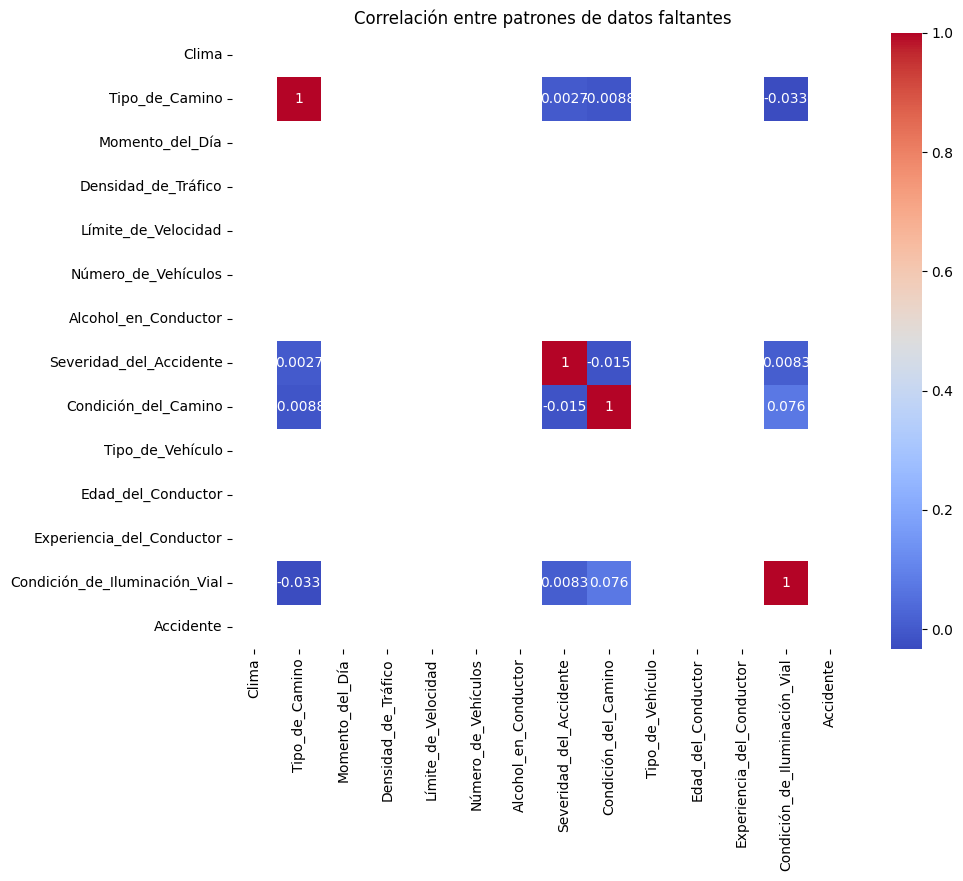

In [ ]:
# Visibilizar el nivel de correlación entre datos faltantes
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(missing_corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre patrones de datos faltantes")
plt.show()

In [ ]:
# ¿Cuántas filas repetidas hay en todo el DataFrame?
df.duplicated().sum()

np.int64(1)

In [ ]:
# Ver las filas que están duplicadas (Muesta una de las que estén repetidas)
filas_duplicadas = df[df.duplicated()]
filas_duplicadas

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
548,Neblinoso,Camino Urbano,Tarde,2.0,40.0,3.0,0.0,NaN,Seco,Auto,18.0,0.0,Luz Diurna,0.0


In [ ]:
#Se muestran todas las filas duplicadas
dups = df[df.duplicated(keep=False)]
dups


,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
39,Neblinoso,Camino Urbano,Tarde,2.0,40.0,3.0,0.0,NaN,Seco,Auto,18.0,0.0,Luz Diurna,0.0
548,Neblinoso,Camino Urbano,Tarde,2.0,40.0,3.0,0.0,NaN,Seco,Auto,18.0,0.0,Luz Diurna,0.0


#### **2-1-1-1 Resultados y conclusiones valores nulos**

*   Los valores nulos no se distribuyen de manera uniforme en las columnas (se concentran los NaN en las variables: Tipo_de_Camino	108
Severidad_del_Accidente	859
Condición_del_Camino	69
Condición_de_Iluminación_Vial).
*   Son pocas las filas que tienen más de un NaN, y solo tres con más de 2.
* En la matriz de correlación de los faltantes no se establece que haya patrones sistemáticos entre los valores faltantes.

Coeficientes de correlación entre -0.03 y +0.07.

Los NaN no siguen un patrón estructurado, es aparentemente aleatorio.

**Conclusión:** Se define un umbral de 1 dato a imputar, solo se conservarán las filas en las que haya 1 o menos de 1 NaN. Filas con ≥2 NaN



#### **2-1-1-2 Resultados y conclusiones tipos de datos**
*   7 columnas numéricas (float64) y 7 categóricas (object).
*   De las 7 columnas con datos numéricos las categorías de "Alcohol_en_conductor" y "Accidente" corresponden a valores binarios.

**Conclusión:** Pandas no identifica los valores binarios como enteros (int64) sino como decimales (float64) por la presencia de valores nulos. los mismos deberán transformarse en valores extremos para evitar tener problemas con otras librerías.




#### **2-1-1-3 Resultados y conclusiones filas repetidas**
*   Se identifica 1 fila repetida.

**Conclusión:** Se elimina la fila repetida.




## **2-1-2 En base a la presencia de Outliers matemáticos**

In [ ]:
#Identificación de valores fuera de rango en columnas según método estadístico
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

outliers = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR

    outliers[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

outliers

{'Densidad_de_Tráfico': 0,
 'Límite_de_Velocidad': 0,
 'Número_de_Vehículos': 26,
 'Alcohol_en_Conductor': 132,
 'Edad_del_Conductor': 0,
 'Experiencia_del_Conductor': 34,
 'Accidente': 0}

In [ ]:
#Valores estadísticamente fuera de rango referidos a la experiencia del conductor
col = 'Experiencia_del_Conductor'

# Calcular cuartiles
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

# Límites para definir outliers
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

# Identificar filas fuera de rango
outliers_experiencia = df[(df[col] < lower) | (df[col] > upper)]

outliers_experiencia

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
18,Tormentoso,Autopista,Mañana,2.0,110.0,1.0,0.0,Media,Mojado,Camion,76.0,57.0,Luz Diurna,1.0
55,Despejado,Camino Rural,Atardecer,0.0,90.0,1.0,0.0,Baja,Seco,Auto,79.0,55.0,NaN,1.0
116,Lluvioso,Camino Rural,Noche,2.0,70.0,1.0,0.0,Baja,Mojado,Auto,75.0,56.0,Sin Luz,1.0
163,Nevado,Autopista,Noche,2.0,110.0,4.0,1.0,Alta,Congelado,Moto,74.0,49.0,Luz Artificial,1.0
209,Despejado,Autopista,Tarde,2.0,100.0,4.0,0.0,Baja,Seco,Auto,74.0,51.0,Luz Diurna,1.0
239,Nevado,Autopista,Mañana,0.0,100.0,4.0,0.0,Media,Seco,Auto,73.0,54.0,Luz Artificial,1.0
275,Despejado,NaN,Tarde,1.0,120.0,4.0,0.0,Baja,Mojado,Auto,72.0,50.0,Luz Diurna,1.0
368,Despejado,Camino Rural,Mañana,1.0,70.0,2.0,0.0,Baja,Seco,Camioneta,69.0,49.0,Luz Diurna,1.0
413,Despejado,Autopista,Noche,2.0,80.0,2.0,0.0,Baja,Seco,Auto,72.0,48.0,Luz Artificial,1.0
420,Tormentoso,Camino Rural,Mañana,2.0,80.0,4.0,0.0,Baja,Mojado,Auto,72.0,53.0,Luz Diurna,1.0


In [ ]:
#Valores estadísticamente fuera de rango referidos a el número de vehículos
col = 'Número_de_Vehículos'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5*IQR
lower = Q1 - 1.5*IQR

outliers_veh = df[(df[col] < lower) | (df[col] > upper)]

outliers_veh

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
229,Tormentoso,Autopista,Mañana,2.0,90.0,8.0,0.0,Media,Mojado,Auto,18.0,0.0,Luz Diurna,1.0
404,Despejado,NaN,Atardecer,2.0,90.0,8.0,0.0,Baja,Mojado,Camioneta,36.0,1.0,Luz Artificial,1.0
435,Despejado,Autopista,Mañana,2.0,80.0,8.0,0.0,Baja,Seco,Auto,52.0,8.0,Luz Diurna,1.0
523,Nevado,Autopista,Atardecer,1.0,110.0,8.0,0.0,Media,Congelado,Camion,41.0,10.0,Luz Artificial,1.0
533,Lluvioso,Autopista,Tarde,2.0,110.0,10.0,0.0,Media,Mojado,Camioneta,55.0,4.0,Luz Diurna,1.0
539,Despejado,Autopista,Tarde,2.0,90.0,8.0,0.0,NaN,Seco,Auto,32.0,1.0,Luz Diurna,0.0
687,Neblinoso,Autopista,Tarde,2.0,100.0,8.0,0.0,NaN,Mojado,Auto,58.0,39.0,Luz Diurna,0.0
943,Despejado,Autopista,Tarde,2.0,100.0,9.0,0.0,NaN,Seco,Auto,53.0,24.0,Luz Diurna,0.0
1011,Despejado,Autopista,Tarde,2.0,80.0,8.0,0.0,NaN,Seco,Auto,43.0,16.0,Luz Diurna,0.0
1032,Despejado,Autopista,Tarde,2.0,90.0,9.0,0.0,Baja,Seco,Auto,34.0,12.0,Luz Diurna,1.0


In [ ]:
# Contar cuántos outliers tienen más de 2 vehículos
casos_mas_2 = outliers_veh[outliers_veh['Número_de_Vehículos'] > 2]

print("Cantidad de casos con más de 2 vehículos:", casos_mas_2.shape[0])
casos_mas_2

Cantidad de casos con más de 2 vehículos: 26


,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
229,Tormentoso,Autopista,Mañana,2.0,90.0,8.0,0.0,Media,Mojado,Auto,18.0,0.0,Luz Diurna,1.0
404,Despejado,NaN,Atardecer,2.0,90.0,8.0,0.0,Baja,Mojado,Camioneta,36.0,1.0,Luz Artificial,1.0
435,Despejado,Autopista,Mañana,2.0,80.0,8.0,0.0,Baja,Seco,Auto,52.0,8.0,Luz Diurna,1.0
523,Nevado,Autopista,Atardecer,1.0,110.0,8.0,0.0,Media,Congelado,Camion,41.0,10.0,Luz Artificial,1.0
533,Lluvioso,Autopista,Tarde,2.0,110.0,10.0,0.0,Media,Mojado,Camioneta,55.0,4.0,Luz Diurna,1.0
539,Despejado,Autopista,Tarde,2.0,90.0,8.0,0.0,NaN,Seco,Auto,32.0,1.0,Luz Diurna,0.0
687,Neblinoso,Autopista,Tarde,2.0,100.0,8.0,0.0,NaN,Mojado,Auto,58.0,39.0,Luz Diurna,0.0
943,Despejado,Autopista,Tarde,2.0,100.0,9.0,0.0,NaN,Seco,Auto,53.0,24.0,Luz Diurna,0.0
1011,Despejado,Autopista,Tarde,2.0,80.0,8.0,0.0,NaN,Seco,Auto,43.0,16.0,Luz Diurna,0.0
1032,Despejado,Autopista,Tarde,2.0,90.0,9.0,0.0,Baja,Seco,Auto,34.0,12.0,Luz Diurna,1.0


###**2-1-2-1 Resultados y conclusiones en relación a outliers matemáticos**

De los datos que estadísticamente se consideran fuera de rango se desprecian los relacionados a la experiencia del conductor ya que los mismos se validan en la busqueda de inconsistencias.

Respecto de la cantidad de vehículos que intervienen en el siniestro. se identifican por encima del límite de 2 vehículos  (establecido para dataset de entrenamiento) 26 casos.


*No se consideran los valores de Outliers para valores que conrresponden a datos binarios.*

**Conclusión:**

No se efectúa ninguna acción en este punto en relación a los datos de experiencia del conductor, pero si se limita la lista a aquellos incidentes que tengan menos de 2 vehículos intervinientes (este criterio se define según la experiencia del equipo experto).

##**2-1-3 Análisis de inconsistencias lógicas**



In [ ]:
# Se identifican nuevamente las columnas con su designación en el df para explorar
# algunas validaciones lógicas
df.columns.tolist()


['Clima',
 'Tipo_de_Camino',
 'Momento_del_Día',
 'Densidad_de_Tráfico',
 'Límite_de_Velocidad',
 'Número_de_Vehículos',
 'Alcohol_en_Conductor',
 'Severidad_del_Accidente',
 'Condición_del_Camino',
 'Tipo_de_Vehículo',
 'Edad_del_Conductor',
 'Experiencia_del_Conductor',
 'Condición_de_Iluminación_Vial',
 'Accidente']

In [ ]:
# Identificar casos de conductores menores de 16 años
menores_16 = df[df['Edad_del_Conductor'] < 16]
menores_16

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente


In [ ]:
# Identificar casos de conductores mayores de 75 años de edad
cantidad_mayores_75 = (df["Edad_del_Conductor"] > 75).sum()
print("Cantidad de conductores mayores de 75 años:", cantidad_mayores_75)


Cantidad de conductores mayores de 75 años: 39


In [ ]:
# Inconsistencia lógica: Conductores cuya edad - experiencia < 16 años.
inconsistencias_manejo = df[(df['Edad_del_Conductor'] - df['Experiencia_del_Conductor']) < 16]

inconsistencias_manejo

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente


In [ ]:
# Inconsistencia lógica: Velocidades irreales en camino urbano
# Se considera que por la presencia de lomadas, de otros vehículos o de badenes en
# las rutas o caminos urbanos dificilmente un vehículo pueda alcanzar los 120km/h
# se considera como dato de entrenamiento que un vehículo en caminos urbanos no supera el límite de velocidad 60km/h

irreales_velocidades_camino_urbano = df[(df['Tipo_de_Camino'] == 'Camino Urbano')
& (df['Límite_de_Velocidad'] > 60)]
irreales_velocidades_camino_urbano


,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente


In [ ]:
# Inconsistencia lógica: si Clima = 'Lluvioso', el camino no puede estar 'Seco'
inconsistencia_lluvia = df[(df['Clima'] == 'Lluvioso') & (df['Condición_del_Camino'] == 'Seco')]

inconsistencia_lluvia

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
26,Lluvioso,Camino Urbano,Atardecer,2.0,60.0,2.0,0.0,NaN,Seco,Auto,40.0,3.0,Luz Artificial,0.0
32,Lluvioso,Autopista,Noche,0.0,100.0,3.0,1.0,Alta,Seco,Bus,18.0,0.0,Luz Artificial,1.0
100,Lluvioso,Autopista,Tarde,2.0,110.0,3.0,0.0,NaN,Seco,Bus,23.0,2.0,Luz Diurna,0.0
258,Lluvioso,Camino Urbano,Noche,0.0,50.0,1.0,0.0,Baja,Seco,Auto,36.0,6.0,Luz Artificial,1.0
380,Lluvioso,Camino Urbano,Atardecer,1.0,60.0,4.0,0.0,Baja,Seco,Auto,46.0,8.0,Luz Diurna,1.0
400,Lluvioso,Camino Rural,Mañana,1.0,70.0,4.0,0.0,NaN,Seco,Moto,40.0,12.0,Luz Diurna,0.0
421,Lluvioso,Autopista,Noche,2.0,90.0,2.0,0.0,Media,Seco,Auto,36.0,1.0,Luz Artificial,1.0
458,Lluvioso,Camino Urbano,Tarde,2.0,40.0,2.0,0.0,NaN,Seco,Auto,51.0,19.0,Luz Diurna,0.0
509,Lluvioso,Camino Urbano,Mañana,2.0,40.0,5.0,0.0,Baja,Seco,Camion,51.0,15.0,Luz Diurna,1.0
522,Lluvioso,Autopista,Tarde,1.0,100.0,5.0,0.0,Media,Seco,Auto,44.0,5.0,Luz Diurna,1.0


In [ ]:
# Inconsistencia lógica: un camión no puede tener un límite de velocidad mayor a 80 km/h porque superaría los límites especificados en las normas de tránsito para velocidades máximas en rutas
inconsistencia_camion_vel = df[
    (df['Tipo_de_Vehículo'] == 'Camión') & (df['Límite_de_Velocidad'] > 80)]

inconsistencia_camion_vel

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente


###**2-1-3-1 Resultados y conclusiones en base a inconsistencias lógicas**
*   No se identifican conductores con edades menores de las mínimas permitidas, tampoco inconsistencias referidas a la edad y experiencia del conductor.

*   Se considera eliminar para entrenamiento los datos de los conductores mayores de 75 años debido a que se reduce significativamente la probabilidad del caso.

*   Teniendo en cuenta las características de los caminos o rutas urbanas (presencia de lomadas, badenes, semáforos y otros vehículos) es muy poco probable que un vehículo en condiciones normales exceda los 120km/h sin embargo como el límite de velocidad dentro de la ciudad es 60km/h se define está velocidad como límite para datos de entrenamiento.

*   Si el clima figura como lluvioso el camino no puede estar seco. Se identifican múltiples casos de este tipo.

*   Teniendo en cuenta las características de un camión normal en ruta. Es muy poco probable que el mismo exceda los 110km/h, sin embargo como el límite de velocidad para camiones en rutas es 80km/h se define está velocidad como límite para datos de entrenamiento.


**Conclusión:**

**Se propone corregir los valores en la medida que sea posible según la siguiente lógica**

*   Respecto de la relación entre la experiencia y la edad del conductor, se verifica que la variable edad no presenta inconsistencias con lo cual se define la experiencia máxima posible restando a la edad la edad a la cual se obtiene el carnet en condiciones normales (18 años). **Para el caso no es necesario.**

*   En relación a los vehículos en el entorno urbano se decide eliminar los datos en los cuales se superan los 60km/h.**Para el caso no es necesario.**

*   Cuando el clima es lluvioso se propone **reemplazar los valores de camino seco por camino mojado**.

*   Se eliminan los casos de camiones que circulen a más de 80km/h. **Para el caso no es necesario.**

#**3-1- Data Claning**

##**3-1-1 Eliminar filas duplicadas**
Se eliminan las filas para evitar su procesamiento posterior.

In [ ]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
df_clean

,Clima,Tipo_de_Camino,Momento_del_Día,Densidad_de_Tráfico,Límite_de_Velocidad,Número_de_Vehículos,Alcohol_en_Conductor,Severidad_del_Accidente,Condición_del_Camino,Tipo_de_Vehículo,Edad_del_Conductor,Experiencia_del_Conductor,Condición_de_Iluminación_Vial,Accidente
0,Despejado,Camino Rural,Atardecer,0.0,70.0,3.0,0.0,NaN,Seco,Camion,49.0,23.0,NaN,0.0
1,Despejado,Camino Urbano,Tarde,2.0,30.0,2.0,1.0,Media,Seco,Auto,22.0,3.0,Luz Diurna,1.0
2,Despejado,Autopista,Atardecer,0.0,100.0,3.0,0.0,NaN,Seco,Moto,41.0,7.0,Luz Diurna,0.0
3,Lluvioso,Camino Urbano,Tarde,2.0,40.0,1.0,0.0,NaN,Mojado,Auto,80.0,24.0,Luz Diurna,0.0
4,Despejado,Autopista,Noche,1.0,110.0,2.0,0.0,NaN,Seco,Bus,32.0,6.0,Luz Artificial,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,Despejado,Autopista,Tarde,2.0,110.0,2.0,0.0,Baja,Seco,Bus,71.0,18.0,Luz Diurna,1.0
1995,Neblinoso,Camino Urbano,Tarde,2.0,60.0,4.0,0.0,Baja,Mojado,Auto,55.0,24.0,Luz Diurna,1.0
1996,Despejado,Camino Rural,Tarde,0.0,70.0,1.0,0.0,NaN,Seco,Auto,80.0,9.0,Luz Diurna,0.0
1997,Nevado,Camino Urbano,Atardecer,0.0,50.0,4.0,0.0,NaN,Seco,Auto,56.0,0.0,Luz Artificial,0.0


In [ ]:
# Mostrar filas eliminadas:

# Copia del dataset original
df_clean = df.copy()

# Cantidad de filas antes de eliminar duplicados
filas_antes = df_clean.shape[0]

# Eliminar duplicados
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Cantidad de filas después
filas_despues = df_clean.shape[0]

# Calcular cuántas filas se eliminaron
eliminadas = filas_antes - filas_despues

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Filas duplicadas eliminadas:", eliminadas)


Filas antes: 2000
Filas después: 1999
Filas duplicadas eliminadas: 1


##**3-1-2 Corregir a formato binario para "Alcohol_en_Conductor" y "Accidente"**
Los mismos deben ser interpretados por Pandas como int 0/1

*Empezamos por accidente que a su vez es la variable objetivo osea que no pede tener valores nulos*

In [ ]:
#TRANSFORMACIÓN DE LA VARIABLE ACCIDENTE
# Copiar para separar y transformar esta variable del dataset original
df_clean = df.copy()

# Convertir valores a numéricos (por si hay strings)
df_clean['Accidente'] = pd.to_numeric(df_clean['Accidente'], errors='coerce')

# Redondear valores enteros 0 o 1
df_clean['Accidente'] = df_clean['Accidente'].round()

# Eliminar filas donde Accidente sea NaN (NO se imputan por ser la variable objetivo)
df_clean = df_clean[~df_clean['Accidente'].isna()].copy()

# Convertir para que el dato esté en entero binario
df_clean['Accidente'] = df_clean['Accidente'].astype('Int64')

# Verificación
print("Tipo:", df_clean['Accidente'].dtype)
print("Valores únicos:", df_clean['Accidente'].unique())

Tipo: Int64
Valores únicos: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64


Ahora transformamos la variable *"Alcohol_en_Conductor", esta variable tambien es binaria y tiene que estar en valores enteros, pero si se puede imputar, se imputa utilizando el valor más frecuente (0= cero) ya que preserva la distribución real y por ser un valor binario no puede usarse la media o la mediana.*

In [ ]:
# TRANSFORMACIÓN DE LA VARIABLE Alcohol_en_Conductor
# Convertir a número por si hay strings
df_clean['Alcohol_en_Conductor'] = pd.to_numeric(df_clean['Alcohol_en_Conductor'], errors='coerce')

# Redondear (por si quedó 0.0 / 1.0)
df_clean['Alcohol_en_Conductor'] = df_clean['Alcohol_en_Conductor'].round()

# Imputar NaN con la moda (valor más frecuente)
moda_alcohol = df_clean['Alcohol_en_Conductor'].mode()[0]
df_clean['Alcohol_en_Conductor'] = df_clean['Alcohol_en_Conductor'].fillna(moda_alcohol)

# Convertir a entero binario tipo Int64
df_clean['Alcohol_en_Conductor'] = df_clean['Alcohol_en_Conductor'].astype('Int64')

# Verificación
print("Tipo:", df_clean['Alcohol_en_Conductor'].dtype)
print("Valores únicos:", df_clean['Alcohol_en_Conductor'].unique())
print("Moda utilizada:", moda_alcohol)

Tipo: Int64
Valores únicos: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64
Moda utilizada: 0.0


##**3-1-3 Soluciones adoptadas para NaN**


###**3-1-3-1 Eliminar filas con más de 1 NaN**
Se resuelve eliminar las filas que tengan más de 1 dato imputado, ya que no aportarían información real.

In [ ]:
#ELIMINAR FILAS CON MÁS DE 1 NA (NaN)
# Contar NaN por fila
na_por_fila = df_clean.isna().sum(axis=1)

# Filtrar solo las filas que tienen 1 o menos NaN
df_clean = df_clean[na_por_fila <= 1].reset_index(drop=True)

# Verificación
print("Filas después de eliminar filas con más de 1 NaN:", df_clean.shape[0])

Filas después de eliminar filas con más de 1 NaN: 1907


###**3-1-3-2 Imputar los valores de NaN que hayan quedado (hasta 1 por fila)**
Los valores numéricos se imputan con la mediana ya que no son variables binarias.
Se aplica a las siguientes variables:
*   Densidad_de_Tráfico
*   Límite_de_Velocidad
*   Número_de_Vehículos
*   Edad_del_Conductor
*   Experiencia_del_Conductor


In [ ]:
#IMPUTACIÓN DE COLUMNAS NUMÉRICAS (NO BINARIAS)
# Definir columnas numéricas reales (float/int) que sí se imputan
num_cols_reales = [
    'Densidad_de_Tráfico',
    'Límite_de_Velocidad',
    'Número_de_Vehículos',
    'Edad_del_Conductor',
    'Experiencia_del_Conductor']
# Imputación con mediana por columna
for col in num_cols_reales:
    mediana = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(mediana)
    print(f"Imputada columna {col} con su mediana: {mediana}")

Imputada columna Densidad_de_Tráfico con su mediana: 1.0
Imputada columna Límite_de_Velocidad con su mediana: 60.0
Imputada columna Número_de_Vehículos con su mediana: 3.0
Imputada columna Edad_del_Conductor con su mediana: 44.0
Imputada columna Experiencia_del_Conductor con su mediana: 11.0


*Se imputan tambien las variables categóricas utilizando el valor más frecuente (moda)*

In [ ]:
#IMPUTACIÓN DE VARIABLES CATEGÓRICAS
# Identificar columnas categóricas automáticamente
cat_cols = df_clean.select_dtypes(include='object').columns
# Imputar cada columna con su moda
for col in cat_cols:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)
    print(f"Columna categórica '{col}' imputada con la moda: {moda}")

Columna categórica 'Clima' imputada con la moda: Despejado
Columna categórica 'Tipo_de_Camino' imputada con la moda: Camino Urbano
Columna categórica 'Momento_del_Día' imputada con la moda: Mañana
Columna categórica 'Severidad_del_Accidente' imputada con la moda: Baja
Columna categórica 'Condición_del_Camino' imputada con la moda: Seco
Columna categórica 'Tipo_de_Vehículo' imputada con la moda: Auto
Columna categórica 'Condición_de_Iluminación_Vial' imputada con la moda: Luz Diurna


##3-1-4 **Eliminar filas con más de 2 vehículos involucrados**
Se eliminan las filas ya que estos valores no corresponden a situaciones habituales, generan ruido en el modelo y puede distorcionar los resultados

In [ ]:
#ELIMINAR FILAS CON MÁS DE 4 VEHÍCULOS
# Cantidad de filas antes de eliminar
filas_antes = df_clean.shape[0]

# Crear máscara de filas inválidas
mask_vehiculos = df_clean['Número_de_Vehículos'] > 4

# Mostrar cuántas filas se eliminarán (informativo)
print("Filas con más de 4 vehículos:", mask_vehiculos.sum())

# Eliminar esas filas
df_clean = df_clean[~mask_vehiculos].reset_index(drop=True)

# Cantidad de filas después de eliminar
filas_despues = df_clean.shape[0]

print("Filas después:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues)

Filas con más de 4 vehículos: 300
Filas después: 1607
Filas eliminadas: 300


In [ ]:
print(df_clean['Número_de_Vehículos'].dtype)
print(df_clean['Número_de_Vehículos'].describe())


float64
count    1607.000000
mean        2.454263
std         1.039203
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: Número_de_Vehículos, dtype: float64


##**3-1-5 Corregir la experiencia del conductor según la edad**
Experiencia del conductor = Edad del conductor - 18 años (edad en la que habitualmente se obtiene el carnet de conducir)

In [ ]:
# Crear la experiencia máxima posible
df_clean['exp_max_posible'] = df_clean['Edad_del_Conductor'] - 18

# Crear la máscara de filas inválidas
mask_invalida = df_clean['Experiencia_del_Conductor'] > df_clean['exp_max_posible']

print("Filas que NO cumplen la regla:", mask_invalida.sum())

# Eliminar esas filas
df_clean = df_clean[~mask_invalida].reset_index(drop=True)

# Quitar la columna auxiliar
df_clean = df_clean.drop(columns=['exp_max_posible'])

# Cantidad de filas después
filas_despues = df_clean.shape[0]

print("Filas después:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues)

Filas que NO cumplen la regla: 0
Filas después: 1607
Filas eliminadas: 300


##**3-1-6  Eliminar los casos de conductores con más de 75 años**

Se decide descartar los casos menos probables para evitar que generen ruido en etapa de entrenamiento.

##**3-1-7 Eliminar registros de caminos urbanos con velocidades mayores a 60km/h**
Se resuelve eliminar las filas en las que se hayan registrado velocidades de 60km/h considerando que esto no es posible por varios factores en zona urbana.

In [ ]:
#ELIMINAR CAMINO URBANO CON VELOCIDADES > 60km/h
# Crear máscara de casos inválidos
mask_urbano_vel = (df_clean['Tipo_de_Camino'] == 'Camino Urbano') & \
                  (df_clean['Límite_de_Velocidad'] > 60)

# Mostrar cuántas filas serán eliminadas (informativo)
print("Registros eliminados (urbano >60 km/h):", mask_urbano_vel.sum())

# Eliminar esas filas
df_clean = df_clean[~mask_urbano_vel].reset_index(drop=True)

# Confirmar dimensiones
print("Nuevas dimensiones del dataset:", df_clean.shape)

Registros eliminados (urbano >60 km/h): 21
Nuevas dimensiones del dataset: (1586, 14)


##**3-1-7 Reemplazar la variable condicion del camino de seco a mojado cuando la definición del clima es lluvioso**
Se reemplazan los valores por inconsistencias técnicas.

In [ ]:
#REEMPLAZAR CONDICIÓN DEL CAMINO: SECO → MOJADO CUANDO EL CLIMA ES LLUVIOSO
# Crear máscara de inconsistencias
mask_lluvia_seco = (df_clean['Clima'] == 'Lluvioso') & \
                   (df_clean['Condición_del_Camino'] == 'Seco')

# Ver cuántas filas se corrigen (informativo)
print("Registros corregidos (Lluvioso + Seco):", mask_lluvia_seco.sum())

# Reemplazar
df_clean.loc[mask_lluvia_seco, 'Condición_del_Camino'] = 'Mojado'

# Confirmar
df_clean['Condición_del_Camino'].value_counts()

Registros corregidos (Lluvioso + Seco): 30


,count
Condición_del_Camino,
Seco,1037
Mojado,452
Congelado,97


##**3-1-8 Eliminar registros de circulación de camiones a más de 80km/h**
Se desestiman estos casos para evitar generar ruido en etapa de entrenamiento

In [ ]:
#ELIMINAR CAMIONES CON VELOCIDADES > 80 KM/H
# Crear máscara para identificar registros inválidos
mask_camion_vel = (df_clean['Tipo_de_Vehículo'] == 'Camión') & \
                  (df_clean['Límite_de_Velocidad'] > 80)

# Mostrar cuántas filas se eliminarán
print("Registros eliminados (Camión >80 km/h):", mask_camion_vel.sum())

# Eliminar esas filas del dataset
df_clean = df_clean[~mask_camion_vel].reset_index(drop=True)

# Confirmar nuevas dimensiones
print("Nuevas dimensiones del dataset:", df_clean.shape)

Registros eliminados (Camión >80 km/h): 0
Nuevas dimensiones del dataset: (1586, 14)


#**4-1- Distribución de la variable objetivo**

Este paso se ejecuta recién ahora ya que el dataset es representativo de la realidad.
Se busca garantizar que la misma se encuentra libre de valores nulos, que está correctamente codificada y que es representativa del fenómeno real.

In [ ]:
#Ver cuantos accidentes hay registrados en el df
df_clean['Accidente'].value_counts()

,count
Accidente,
1,943
0,643


In [ ]:
#Porcentaje de cada clase
df_clean['Accidente'].value_counts(normalize=True)

,proportion
Accidente,
1,0.594578
0,0.405422


**Desvalance leve de clases= Trabajable**

0.40 → 40% de los casos son sin accidente

0.60 → 60% de los casos son con accidente



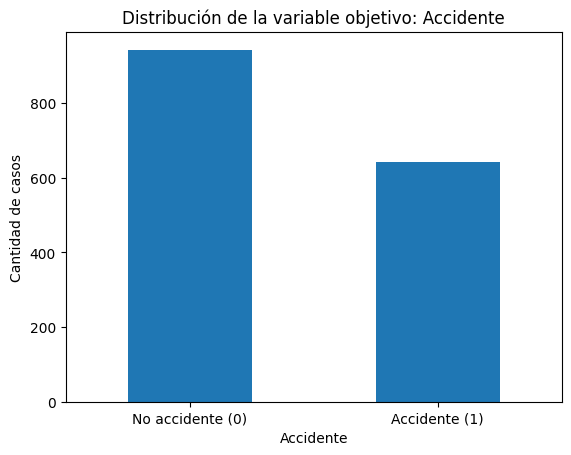

In [ ]:
#CREAR GRAFICO DE BARRAS
import matplotlib.pyplot as plt

df_clean['Accidente'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['No accidente (0)', 'Accidente (1)'], rotation=0)
plt.ylabel('Cantidad de casos')
plt.title('Distribución de la variable objetivo: Accidente')
plt.show()

#**5-1- Verificaciones finales**

*   Qué no queden NaN
*   Qué los tipos de datos estén correctos

categóricas → object

numéricas → float64/int64

binarias → Int64

*   Recodificar columnas categóricas




In [ ]:
#Limpieza de NaN accidentales
df_clean.isna().sum()


,0
Clima,0
Tipo_de_Camino,0
Momento_del_Día,0
Densidad_de_Tráfico,0
Límite_de_Velocidad,0
Número_de_Vehículos,0
Alcohol_en_Conductor,0
Severidad_del_Accidente,0
Condición_del_Camino,0
Tipo_de_Vehículo,0


In [ ]:
#Verificación tipos de datos
df_clean.dtypes

,0
Clima,object
Tipo_de_Camino,object
Momento_del_Día,object
Densidad_de_Tráfico,float64
Límite_de_Velocidad,float64
Número_de_Vehículos,float64
Alcohol_en_Conductor,Int64
Severidad_del_Accidente,object
Condición_del_Camino,object
Tipo_de_Vehículo,object


In [ ]:
#Recodificación categóricas
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip().str.lower()


#**6-1- Gráficos relacionados a las exploraciones**


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
# Configuación del estilo
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

/tmp/ipython-input-196337333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, ax=ax, palette=["salmon", "skyblue"])
/tmp/ipython-input-196337333.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Accidente', 'Accidente'])


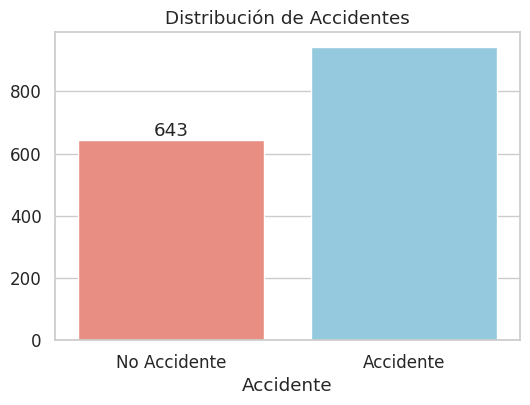

In [ ]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(6,4))

conteo = df_clean['Accidente'].value_counts()

sns.barplot(x=conteo.index, y=conteo.values, ax=ax, palette=["salmon", "skyblue"])
ax.set_xticklabels(['No Accidente', 'Accidente'])
ax.set_title("Distribución de Accidentes")
ax.bar_label(ax.containers[0])

plt.show()

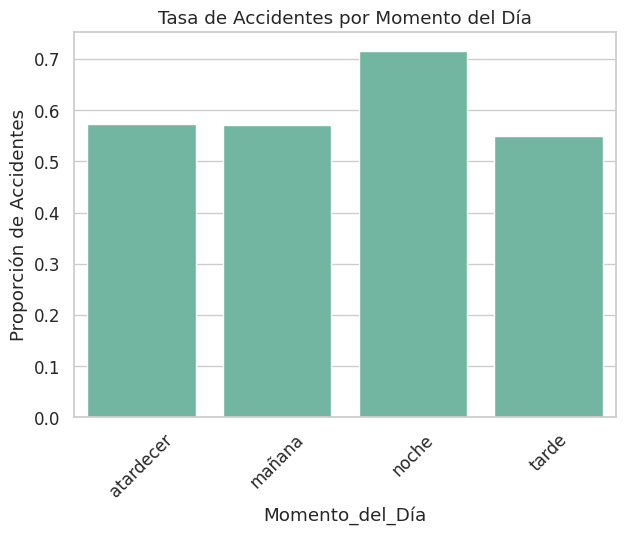

In [ ]:
# Tasa de Accidentes según clima
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(7, 5))

tasa_momento = df_clean.groupby('Momento_del_Día')['Accidente'].mean()

sns.barplot(x=tasa_momento.index, y=tasa_momento.values, ax=ax)
ax.set_title("Tasa de Accidentes por Momento del Día")
ax.set_ylabel("Proporción de Accidentes")
ax.tick_params(axis='x', rotation=45)

plt.show()

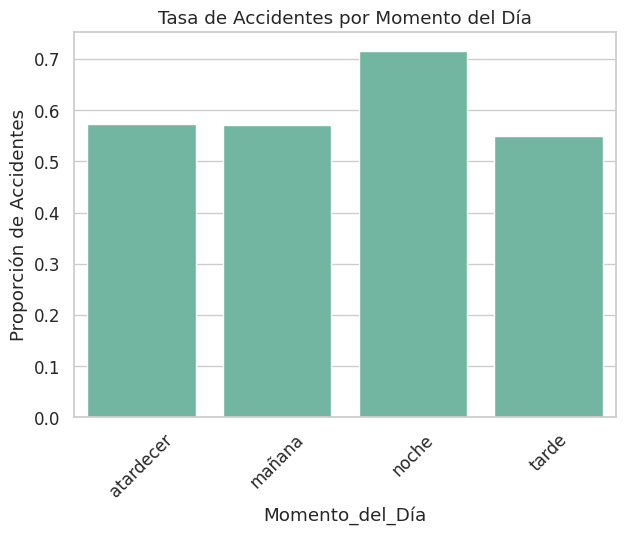

In [ ]:
# Tasa de accidentes según el momento del día
import matplotlib.pyplot as plt
import seaborn as sns

# Crear 1 fila y 3 columnas para que exista axes[2]
fig, ax = plt.subplots(figsize=(7, 5))

tasa_momento = df_clean.groupby('Momento_del_Día')['Accidente'].mean()

sns.barplot(x=tasa_momento.index, y=tasa_momento.values, ax=ax)
ax.set_title("Tasa de Accidentes por Momento del Día")
ax.set_ylabel("Proporción de Accidentes")
ax.tick_params(axis='x', rotation=45)

plt.show()

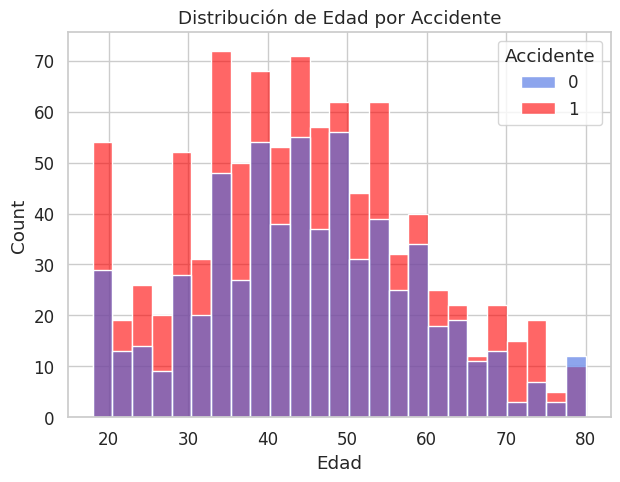

In [ ]:
# Distribución de los accidentes según la edad del conductor
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(
    data=df_clean,
    x='Edad_del_Conductor',
    hue='Accidente',
    kde=False,
    bins=25,
    ax=ax,
    palette=["royalblue", "red"],
    alpha=0.6
)

ax.set_title("Distribución de Edad por Accidente")
ax.set_xlabel("Edad")

plt.show()

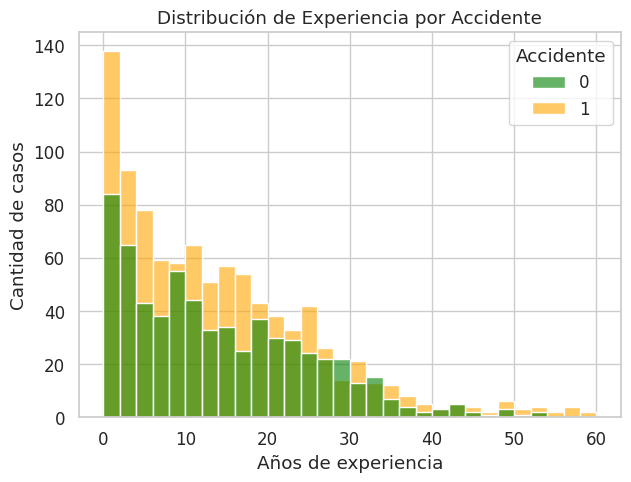

In [ ]:
# Distribución de los accidentes según experiencia del conductor
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(
    data=df_clean,
    x='Experiencia_del_Conductor',
    hue='Accidente',
    kde=False,
    bins=30,
    ax=ax,
    palette=["green", "orange"],
    alpha=0.6
)

ax.set_title("Distribución de Experiencia por Accidente")
ax.set_xlabel("Años de experiencia")
ax.set_ylabel("Cantidad de casos")

plt.show()

/tmp/ipython-input-455847908.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


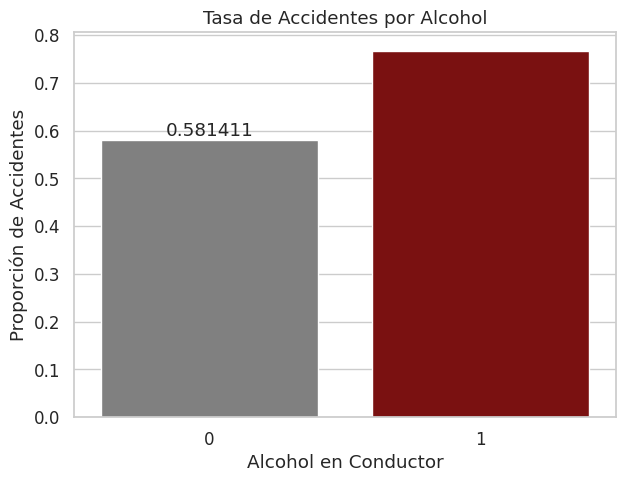

In [ ]:
# Tasa de accidentes según consumo de alcohol
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))

tasa_alcohol = df_clean.groupby('Alcohol_en_Conductor')['Accidente'].mean()

sns.barplot(
    x=tasa_alcohol.index.astype(str),
    y=tasa_alcohol.values,
    ax=ax,
    palette=["gray", "darkred"]
)

ax.set_title("Tasa de Accidentes por Alcohol")
ax.set_xlabel("Alcohol en Conductor")
ax.set_ylabel("Proporción de Accidentes")
ax.bar_label(ax.containers[0])

plt.show()

In [ ]:
# Se guarda el dataset curado en la carpeta de drive
from google.colab import drive
drive.mount('/content/drive')
df_clean.to_csv(
    "/content/drive/MyDrive/IA- Sistema predictivo de accidentes en rutas/00- Datasets/Curados/dataset_entrenamiento_curado.csv",
    index=False
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
